# Анализ и обработка данных на Python

## Содержание

0. Установка Anaconda и запуск Jupyter Notebook
1. Подготовка среды и загрузка библиотек
2. Генерация и первичный анализ датасета
3. Вывод и интерпретация основных статистик
4. Полный пайплайн обработки данных
5. Визуализация данных
6. Практикум

В практикуме (раздел 6) после каждого блока нужно записать вывод **в ячейке markdown прямо в блокноте**.


## 0. Установка Anaconda и запуск Jupyter Notebook

Для работы с блокнотом рекомендуется дистрибутив **Anaconda** — он включает Python, среду Jupyter Notebook и необходимые библиотеки.

1. Скачать установщик: https://www.anaconda.com/download
2. Установить с параметрами по умолчанию.
3. Запустить Anaconda Navigator -> jupyter notebook либо в терминале выполнить:

```bash
jupyter notebook
```

4. В открывшемся окне браузера открыть файл текущего блокнота (`.ipynb`).

**Примечание.** Материалы курса (включая этот блокнот) можно также выполнять в облачной среде Google Colab без локальной установки Anaconda.


## 1. Подготовка среды и загрузка библиотек

Для работы понадобятся:

- `pandas` — для работы с таблицами;
- `numpy` — для математических и векторных операций;
- `matplotlib` и `seaborn` — для построения графиков.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

print("Библиотеки загружены.")
print("Версия pandas:", pd.__version__)
print("Версия numpy:", np.__version__)


Библиотеки загружены.
Версия pandas: 2.3.3
Версия numpy: 2.4.4


## 2. Генерация и первичный осмотр датасета

Датасет ниже имитирует выгрузку из CRM-системы интернет-магазина: данные сгенерированы синтетически, но приближены к реальным. Параметры генерации в ячейке ниже можно изменить, однако в этом случае корректная работа последующих шагов не гарантируется.

В данных намеренно заложены типичные проблемы: дубликаты заказов, пропуски, аномальные значения и т.д.


In [2]:
np.random.seed(42)
n_rows = 250

# Идентификаторы заказа и клиента
order_ids = np.random.choice(range(1001, 1201), n_rows)
customer_ids = np.random.choice(range(1, 121), n_rows)

# Даты заказов
start_date = pd.Timestamp("2025-01-01")
order_dates = start_date + pd.to_timedelta(np.random.randint(0, 300, n_rows), unit="D")

# Категории и регионы
categories = np.random.choice(
    ['Электроника', 'Одежда', 'Книги', 'Дом', 'Спорт'],
    n_rows, p=[0.28, 0.32, 0.18, 0.12, 0.10]
)
regions = np.random.choice(
    ['Москва', 'Санкт-Петербург', 'Регионы'],
    n_rows, p=[0.35, 0.20, 0.45]
)

# Цена и скидка (в цене есть пропуски)
price = np.random.choice(
    [1500, 3500, 12000, 45000, 85000, np.nan],
    n_rows, p=[0.28, 0.28, 0.20, 0.12, 0.07, 0.05]
)
quantity = np.random.randint(1, 5, n_rows)
discount_pct = np.random.choice([0, 5, 10, 15, 20], n_rows, p=[0.40, 0.25, 0.20, 0.10, 0.05])

# Возраст клиентов
customer_age = np.random.choice(
    [19, 25, 34, 45, 52, 120, np.nan],
    n_rows, p=[0.20, 0.28, 0.20, 0.15, 0.07, 0.02, 0.08]
)

# Статус участия в программе лояльности (есть пропуски)
is_member = np.random.choice(['True', 'False', None], n_rows, p=[0.55, 0.32, 0.13])

# Способ оплаты
payment_method = np.random.choice(
    [' карта', 'Карта', 'КАРТА', 'наличные', ' Наличные ', 'СБП', 'сбп'],
    n_rows
)

data = {
    'Order_ID': order_ids,
    'Customer_ID': customer_ids,
    'Order_Date': order_dates,
    'Category': categories,
    'Region': regions,
    'Price': price,
    'Quantity': quantity,
    'Discount_%': discount_pct,
    'Customer_Age': customer_age,
    'Is_Member': is_member,
    'Payment_Method': payment_method,
}

df = pd.DataFrame(data)

# Добавляем дубликаты строк
df = pd.concat([df, df.sample(5, random_state=1)], ignore_index=True)


Первичный осмотр сгенерированных данных.

In [3]:
print("Размер таблицы:", df.shape)
df.head()


Размер таблицы: (255, 11)


,Order_ID,Customer_ID,Order_Date,Category,Region,Price,Quantity,Discount_%,Customer_Age,Is_Member,Payment_Method
0,1103,20,2025-09-26,Электроника,Москва,12000.0,4,5,NaN,None,Наличные
1,1180,59,2025-05-04,Электроника,Регионы,85000.0,1,0,34.0,True,карта
2,1093,36,2025-04-16,Одежда,Регионы,1500.0,2,0,52.0,True,наличные
3,1015,19,2025-06-07,Дом,Регионы,12000.0,2,0,34.0,False,СБП
4,1107,90,2025-05-27,Спорт,Москва,85000.0,4,5,34.0,True,Карта


In [4]:
df.tail(10)

,Order_ID,Customer_ID,Order_Date,Category,Region,Price,Quantity,Discount_%,Customer_Age,Is_Member,Payment_Method
245,1124,99,2025-07-16,Дом,Санкт-Петербург,12000.0,4,15,19.0,False,карта
246,1187,55,2025-01-10,Электроника,Москва,1500.0,4,0,25.0,None,сбп
247,1070,40,2025-10-13,Одежда,Регионы,45000.0,4,0,19.0,True,СБП
248,1093,52,2025-08-30,Электроника,Регионы,3500.0,1,0,25.0,False,СБП
249,1003,16,2025-09-08,Книги,Москва,3500.0,3,20,45.0,True,СБП
250,1035,99,2025-06-09,Спорт,Санкт-Петербург,1500.0,4,10,34.0,False,КАРТА
251,1003,16,2025-09-08,Книги,Москва,3500.0,3,20,45.0,True,СБП
252,1160,97,2025-01-28,Электроника,Санкт-Петербург,45000.0,2,10,45.0,None,сбп
253,1187,46,2025-06-17,Спорт,Москва,3500.0,4,20,NaN,True,КАРТА
254,1082,17,2025-04-15,Одежда,Москва,1500.0,3,10,25.0,True,сбп


Сводная информация по структуре таблицы и типам столбцов.

In [13]:
# Здесь уже можно быстро понять структуру таблицы и где есть пропуски
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        255 non-null    int32         
 1   Customer_ID     255 non-null    int32         
 2   Order_Date      255 non-null    datetime64[ns]
 3   Category        255 non-null    object        
 4   Region          255 non-null    object        
 5   Price           239 non-null    float64       
 6   Quantity        255 non-null    int32         
 7   Discount_%      255 non-null    int32         
 8   Customer_Age    232 non-null    float64       
 9   Is_Member       221 non-null    object        
 10  Payment_Method  255 non-null    object        
dtypes: datetime64[ns](1), float64(2), int32(4), object(4)
memory usage: 18.1+ KB


**Примечание.** Столбец `Order_Date` имеет тип `datetime64`, а не строковый — `pd.to_timedelta` сразу возвращает корректный тип. При загрузке данных из внешнего файла (например, `.csv`) даты, как правило, приходится преобразовывать вручную с помощью `pd.to_datetime()`.


## 3. Вывод и интерпретация основных статистик

Прежде чем чистить данные, нужно понять их «природу». Для этого рассчитывают описательные статистики.

### Математический аппарат

**Выборочное среднее ($\bar{x}$):**

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

*Смысл:* центр тяжести данных. Чувствительно к аномалиям (выбросам).

**Медиана ($Me$ или $Q_2$):** значение, делящее отсортированный ряд ровно пополам. Устойчива к выбросам.

**Мода ($Mo$):** наиболее часто встречающееся значение. Применима и к числам, и к категориям (тексту).

**Квантили / перцентили ($Q_1$, $Q_3$):**
- $Q_1$ (25-й перцентиль) — 25% данных лежат ниже этого значения;
- $Q_3$ (75-й перцентиль) — 75% данных лежат ниже этого значения.

**Межквартильный размах:**

$$IQR = Q_3 - Q_1$$

*Смысл:* диапазон, в котором лежат центральные 50% наблюдений. Границы «нормальных» значений по правилу Тьюки:

$$[\,Q_1 - 1.5 \cdot IQR,\;\; Q_3 + 1.5 \cdot IQR\,]$$

**Дисперсия ($s^2$) и стандартное отклонение ($s$):**

$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2, \qquad s = \sqrt{s^2}$$

*Смысл:* мера разброса значений вокруг среднего.

**Коэффициент вариации ($CV$)** — позволяет сравнивать разброс признаков с разными единицами измерения (например, цену в рублях и возраст в годах):

$$CV = \frac{s}{\bar{x}} \times 100\%$$

Чем выше $CV$, тем менее однороден признак относительно своего среднего значения.


In [9]:
# Смотрим основные описательные статистики по числовым столбцам
display(df.describe())


,Order_ID,Customer_ID,Order_Date,Price,Quantity,Discount_%,Customer_Age
count,255.000000,255.000000,255,239.000000,255.000000,255.000000,232.000000
mean,1101.368627,59.309804,2025-06-01 11:51:31.764705792,18150.627615,2.525490,5.921569,32.612069
min,1001.000000,1.000000,2025-01-01 00:00:00,1500.000000,1.000000,0.000000,19.000000
25%,1052.000000,29.000000,2025-03-30 12:00:00,1500.000000,2.000000,0.000000,25.000000
50%,1103.000000,55.000000,2025-06-05 00:00:00,3500.000000,2.000000,5.000000,29.500000
75%,1151.000000,93.000000,2025-08-11 00:00:00,28500.000000,4.000000,10.000000,45.000000
max,1200.000000,120.000000,2025-10-19 00:00:00,85000.000000,4.000000,20.000000,120.000000
std,58.280457,34.908572,NaN,24645.774299,1.104009,6.037426,14.683838


In [11]:
# Для расчётов по возрасту убираем пропуски
age_series = df['Customer_Age'].dropna()

mean_age = age_series.mean()
median_age = age_series.median()
mode_age = age_series.mode()[0]
q1_age = age_series.quantile(0.25)
q3_age = age_series.quantile(0.75)
iqr_age = q3_age - q1_age
std_age = age_series.std()
cv_age = std_age / mean_age * 100

print(f"Средний возраст: {mean_age:.1f}")
print(f"Медианный возраст: {median_age:.1f}")
print(f"Мода возраста: {mode_age}")
print(f"25-й перцентиль (Q1): {q1_age}")
print(f"75-й перцентиль (Q3): {q3_age}")
print(f"Межквартильный размах (IQR): {iqr_age}")
print(f"Стандартное отклонение: {std_age:.1f}")
print(f"Коэффициент вариации: {cv_age:.1f}%")


Средний возраст: 32.6
Медианный возраст: 29.5
Мода возраста: 25.0
25-й перцентиль (Q1): 25.0
75-й перцентиль (Q3): 45.0
Межквартильный размах (IQR): 20.0
Стандартное отклонение: 14.7
Коэффициент вариации: 45.0%


In [12]:
def iqr_bounds(series):
    # Границы нормальных значений по правилу 1.5*IQR
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

lower_age, upper_age = iqr_bounds(age_series)
print(f"Границы нормальных значений возраста: [{lower_age:.1f}, {upper_age:.1f}]")
print("Аномальных значений возраста (вне границ):", ((age_series < lower_age) | (age_series > upper_age)).sum())


Границы нормальных значений возраста: [-5.0, 75.0]
Аномальных значений возраста (вне границ): 3


### Задачи на расчёт статистик

**Задача 1.**
Вычислите моду для столбца `Category` (самая популярная категория товаров).


In [17]:
mode_category = df['Category'].mode()[0]
print("Самая популярная категория:", mode_category)
print("Количество заказов:", (df['Category'] == mode_category).sum())

Самая популярная категория: Одежда
Количество заказов: 83


**Задача 2.**
Посчитайте 90-й перцентиль для столбца `Price`. Ниже, в отдельной ячейке markdown, письменно поясните, что означает полученное число для отдела продаж.


In [18]:
p90_price = df['Price'].quantile(0.9)
print(f"90-й перцентиль цены: {p90_price:.0f} руб.")

90-й перцентиль цены: 45000 руб.


**Ваше обоснование:**
90-й перцентиль показывает, что 90% всех заказов имеют цену ниже этой отметки, а выше  только 10%. 

Для отдела продаж: основная масса продаж сосредоточена в диапазоне до этого значения.



**Задача 3.**
Используя функцию `iqr_bounds()`, определённую выше, найдите границы нормальных значений для столбца `Price` (без NaN — используйте `df['Price'].dropna()`). Посчитайте количество и долю заказов, цена которых выходит за эти границы.


In [19]:
price_series = df['Price'].dropna()
lower_price, upper_price = iqr_bounds(price_series)

n_outliers = ((price_series < lower_price) | (price_series > upper_price)).sum()
share_outliers = n_outliers / len(price_series) * 100

print(f"Границы нормальных цен: [{lower_price:.0f}, {upper_price:.0f}]")
print(f"Выбросов: {n_outliers} ({share_outliers:.1f}%)")

Границы нормальных цен: [-39000, 69000]
Выбросов: 18 (7.5%)


**Задача 4.**
Посчитайте коэффициент вариации ($CV$) отдельно для `Price` и для `Customer_Age` (оба раза без NaN). У какого признака относительный разброс выше? Дайте ответ в отдельной ячейке markdown.


In [20]:
cv_price = df['Price'].std() / df['Price'].mean() * 100
cv_age = df['Customer_Age'].std() / df['Customer_Age'].mean() * 100

print(f"CV цены: {cv_price:.1f}%")
print(f"CV возраста: {cv_age:.1f}%")


CV цены: 135.8%
CV возраста: 45.0%


**Ваш ответ:**

Относительный разброс выше у цен, чем у возраста.  Цены заказов крайне неоднородны — разброс превышает среднее значение. Возраст клиентов, наоборот, стабилен: основная масса покупателей — 25–45 лет.

## 4. Полный пайплайн обработки данных

Далее данные последовательно очищаются по следующей схеме:

$$\text{Сырые данные} \rightarrow \text{Дубликаты} \rightarrow \text{Пропуски} \rightarrow \text{Типы и аномалии} \rightarrow \text{Выбросы} \rightarrow \text{Новые признаки} \rightarrow \text{Чистый датасет}$$

**Примечание.** Набор необходимых этапов зависит от конкретного датасета и определяется по результатам предварительного анализа (например, вывода `.info()`); выполнять все шаги подряд не всегда обязательно.


### Шаг 1. Поиск и удаление дубликатов

Полные дубликаты строк — это, как правило, ошибка выгрузки (одна и та же запись попала в отчёт дважды). Дубликаты по `Order_ID` — это уже дубликаты по бизнес-ключу: в нашем сценарии предполагается, что один `Order_ID` соответствует одному заказу, поэтому повторы по этому столбцу тоже нужно убрать.


In [22]:
# Проверяем дубликаты: полные и по Order_ID
print("Полных дубликатов строк:", df.duplicated().sum())
print("Дубликатов по Order_ID:", df.duplicated(subset=['Order_ID']).sum())

df_clean = df.drop_duplicates().copy()
df_clean = df_clean.drop_duplicates(subset=['Order_ID'], keep='first').copy()

print("Строк было:", len(df), "-> строк осталось:", len(df_clean))


Полных дубликатов строк: 5
Дубликатов по Order_ID: 120
Строк было: 255 -> строк осталось: 135


### Шаг 2. Обработка пропущенных значений

Для разных столбцов используются разные стратегии заполнения — единого правила «на все случаи» не существует.


In [23]:
print("Пропуски до обработки:")
print(df_clean.isna().sum())


Пропуски до обработки:
Order_ID           0
Customer_ID        0
Order_Date         0
Category           0
Region             0
Price             10
Quantity           0
Discount_%         0
Customer_Age      17
Is_Member         17
Payment_Method     0
dtype: int64


Например, пропуски можно заполнить вполне конкретными значениями

In [24]:
# Цена — медиана по категории
df_clean['Price'] = df_clean.groupby('Category')['Price'].transform(lambda x: x.fillna(x.median()))

# Возраст — общая медиана
df_clean['Customer_Age'] = df_clean['Customer_Age'].fillna(df_clean['Customer_Age'].median())

# Статус участия — отдельная категория 'Unknown'
df_clean['Is_Member'] = df_clean['Is_Member'].fillna('Unknown')

print("Пропуски после обработки:")
print(df_clean.isna().sum())


Пропуски после обработки:
Order_ID          0
Customer_ID       0
Order_Date        0
Category          0
Region            0
Price             0
Quantity          0
Discount_%        0
Customer_Age      0
Is_Member         0
Payment_Method    0
dtype: int64


**Примечание.** Альтернативный подход — удаление строк с пропусками. Он оправдан, когда датасет достаточно велик, а удаляемые строки не оказывают существенного влияния на выборку в целом.


### Шаг 3. Исправление типов данных и аномалий


In [25]:
# Приводим возраст к целочисленному типу
df_clean['Customer_Age'] = df_clean['Customer_Age'].astype(int)

# Аномальные значения (например, 120 лет) заменяем медианой
median_age_clean = int(df_clean['Customer_Age'].median())
df_clean.loc[df_clean['Customer_Age'] > 100, 'Customer_Age'] = median_age_clean

print("Максимальный возраст после исправления:", df_clean['Customer_Age'].max())


Максимальный возраст после исправления: 52


**Примечание.** Пороговое значение 100 лет выбрано как условная граница и может быть скорректировано с учётом специфики реальных данных.


### Шаг 4. Обработка выбросов по цене

Используем функцию `iqr_bounds()` из раздела статистики, чтобы «прижать» (capping) экстремальные значения цены к границам нормального диапазона, а не удалять строки целиком — это позволяет не терять заказы по остальным признакам.


In [26]:
# Определяем границы IQR и считаем выбросы
lower_price, upper_price = iqr_bounds(df_clean['Price'])
n_outliers_price = ((df_clean['Price'] < lower_price) | (df_clean['Price'] > upper_price)).sum()
print(f"Границы нормальной цены: [{lower_price:.0f}, {upper_price:.0f}]")
print("Выбросов по цене:", n_outliers_price)

# Ограничиваем значения границами вместо удаления строк
df_clean['Price'] = df_clean['Price'].clip(lower=lower_price, upper=upper_price)


Границы нормальной цены: [-14250, 27750]
Выбросов по цене: 29


### Шаг 5. Создание новых признаков (Feature Engineering)


Выбор новых признаков определяется задачей анализа и требованиями пользователей, заказчика или внешних партнёров (вендоров). Например, итоговая сумма заказа рассчитывается как:

$$Total\_Amount = Price \times Quantity \times \left(1 - \frac{Discount\_\%}{100}\right)$$

**Практическая применимость:** именно `Total_Amount`, а не исходная `Price`, отражает фактическую выручку по заказу и используется во всех дальнейших агрегатах (средний чек, суммарная выручка, ARPU).


In [27]:
# Итоговая сумма заказа с учётом скидки
df_clean['Total_Amount'] = (
    df_clean['Price'] * df_clean['Quantity'] * (1 - df_clean['Discount_%'] / 100)
).round(2)

# Месяц заказа
df_clean['Order_Month'] = df_clean['Order_Date'].dt.month

df_clean.head()


,Order_ID,Customer_ID,Order_Date,Category,Region,Price,Quantity,Discount_%,Customer_Age,Is_Member,Payment_Method,Total_Amount,Order_Month
0,1103,20,2025-09-26,Электроника,Москва,12000.0,4,5,25,Unknown,Наличные,45600.0,9
1,1180,59,2025-05-04,Электроника,Регионы,27750.0,1,0,34,True,карта,27750.0,5
2,1093,36,2025-04-16,Одежда,Регионы,1500.0,2,0,52,True,наличные,3000.0,4
3,1015,19,2025-06-07,Дом,Регионы,12000.0,2,0,34,False,СБП,24000.0,6
4,1107,90,2025-05-27,Спорт,Москва,27750.0,4,5,34,True,Карта,105450.0,5


### Задачи на обработку данных

**Задача 5.**
Переведите значения столбца `Is_Member` из строк `'True'` / `'False'` в логический тип `bool`, а значения `'Unknown'` — в `pd.NA` (пропуск).


In [28]:
df_clean['Is_Member'] = df_clean['Is_Member'].map({
    'True': True,
    'False': False,
    'Unknown': pd.NA
})

print(df_clean['Is_Member'].value_counts(dropna=False))
print("Тип:", df_clean['Is_Member'].dtype)

Is_Member
True     76
False    42
<NA>     17
Name: count, dtype: int64
Тип: object


**Задача 6.**
Создайте новый категориальный столбец `Age_Group` со значениями:

- `'Youth'` — возраст меньше 30 лет;
- `'Adult'` — возраст от 30 до 50 лет включительно;
- `'Senior'` — возраст больше 50 лет.


In [29]:
df_clean['Age_Group'] = pd.cut(
    df_clean['Customer_Age'],
    bins=[0, 30, 51, 200],
    labels=['Youth', 'Adult', 'Senior'],
    right=False
)

print(df_clean['Age_Group'].value_counts())

Age_Group
Youth     81
Adult     47
Senior     7
Name: count, dtype: int64


**Задача 7.**
Найдите категории товаров, у которых **средняя выручка на чек** (`Total_Amount`) выше, чем **медианная выручка по всему датасету**.


In [30]:
median_total = df_clean['Total_Amount'].median()
mean_by_cat = df_clean.groupby('Category')['Total_Amount'].mean()

result = mean_by_cat[mean_by_cat > median_total].sort_values(ascending=False)

print(f"Медиана Total_Amount по всему датасету: {median_total:.0f} руб.")
print("\nКатегории со средним чеком выше медианы:")
print(result)


Медиана Total_Amount по всему датасету: 11400 руб.

Категории со средним чеком выше медианы:
Category
Спорт          30187.500000
Книги          24843.421053
Электроника    24478.273810
Одежда         21769.642857
Дом            21677.777778
Name: Total_Amount, dtype: float64


**Задача 8.**
Столбец `Payment_Method` содержит «грязный» текст: лишние пробелы и разный регистр (` карта`, `Карта`, `КАРТА`), а также два варианта написания одного способа оплаты (`СБП`, `сбп`). Приведите значения к единому виду.

После обработки с помощью `value_counts()` убедитесь, что остались ровно три уникальных значения: `Карта`, `Наличные`, `Сбп`.

Сохраните результат в тот же столбец `Payment_Method`.


In [31]:
df_clean['Payment_Method'] = (
    df_clean['Payment_Method']
    .str.strip()
    .str.lower()
    .replace({
        'карта': 'Карта',
        'наличные': 'Наличные',
        'сбп': 'Сбп'
    })
)

print(df_clean['Payment_Method'].value_counts())

Payment_Method
Карта       59
Наличные    38
Сбп         38
Name: count, dtype: int64


## Визуализация данных

График — эффективный способ представить выводы коллегам и руководству, а также быстрее разобраться в структуре и особенностях данных.


### 1. Гистограмма

*Для чего:* понять, как часто встречаются разные значения числового признака.


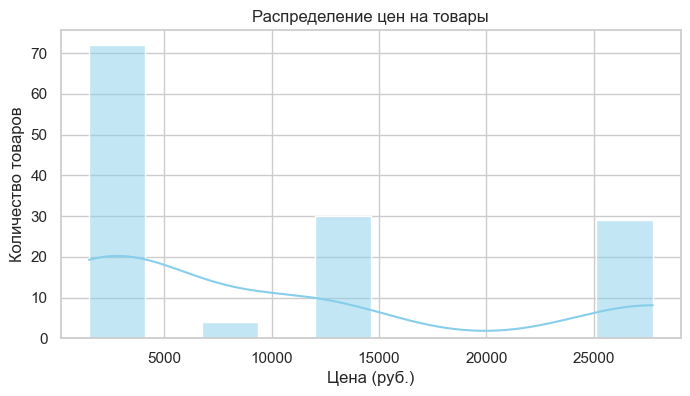

In [32]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['Price'], bins=10, kde=True, color='skyblue')
plt.title('Распределение цен на товары')
plt.xlabel('Цена (руб.)')
plt.ylabel('Количество товаров')
plt.show()


### 2. Ящик с усами (boxplot)

*Для чего:* наглядно увидеть медиану, квартили ($Q_1$, $Q_3$) и **особенно** выбросы.


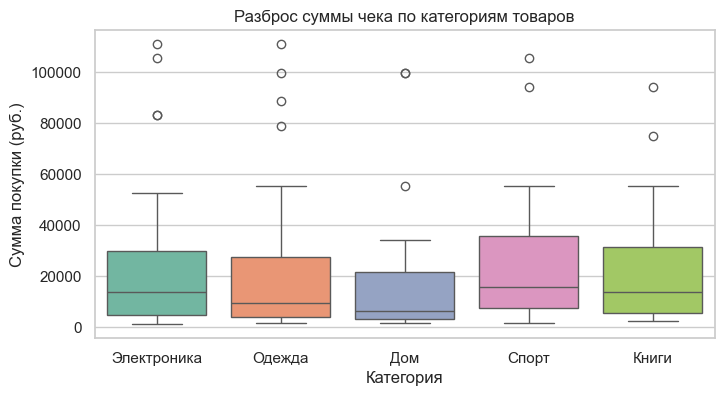

In [33]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='Category', y='Total_Amount', hue='Category', data=df_clean, palette='Set2', legend=False)
plt.title('Разброс суммы чека по категориям товаров')
plt.xlabel('Категория')
plt.ylabel('Сумма покупки (руб.)')
plt.show()


### 3. Столбчатая диаграмма (bar chart)

*Для чего:* сравнить агрегированные показатели по категориям.


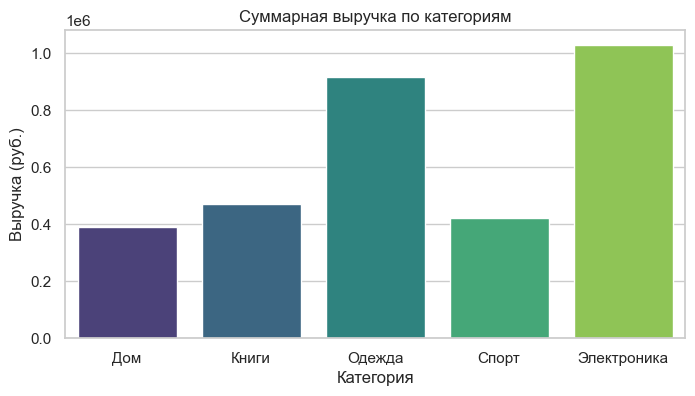

In [34]:
category_revenue = df_clean.groupby('Category')['Total_Amount'].sum().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(x='Category', y='Total_Amount', hue='Category', data=category_revenue, palette='viridis', legend=False)
plt.title('Суммарная выручка по категориям')
plt.xlabel('Категория')
plt.ylabel('Выручка (руб.)')
plt.show()


### 4. Точечный график (scatter plot)

*Для чего:* посмотреть на совместное поведение двух числовых переменных.


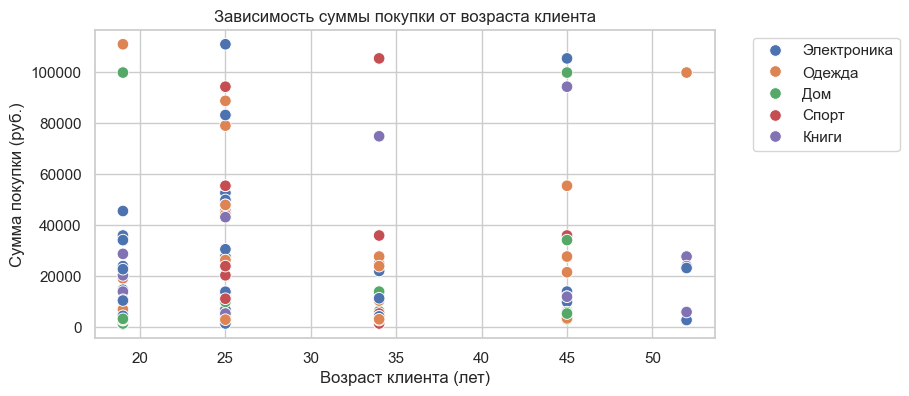

In [35]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x='Customer_Age', y='Total_Amount', hue='Category', data=df_clean, s=70)
plt.title('Зависимость суммы покупки от возраста клиента')
plt.xlabel('Возраст клиента (лет)')
plt.ylabel('Сумма покупки (руб.)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


### 5. Линейный график 

*Для чего:* показать изменение показателя в разрезе времени — рост, падение, сезонность.


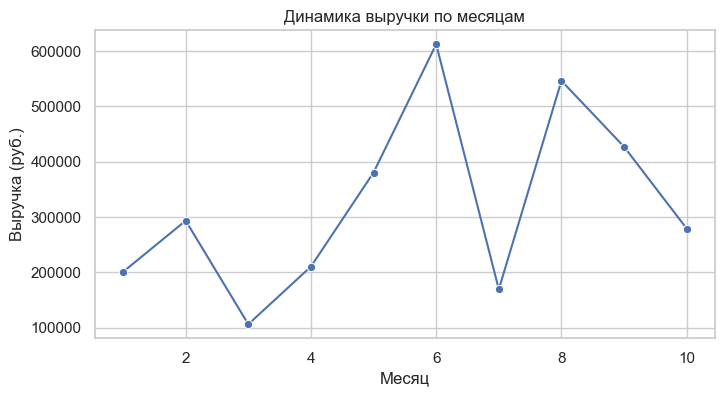

In [36]:
monthly_revenue = df_clean.groupby('Order_Month')['Total_Amount'].sum()

plt.figure(figsize=(8, 4))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o')
plt.title('Динамика выручки по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка (руб.)')
plt.show()


### Задачи на визуализацию

**Задача 9.**
Постройте гистограмму распределения возраста клиентов. Задайте `bins=8` и цвет столбцов.


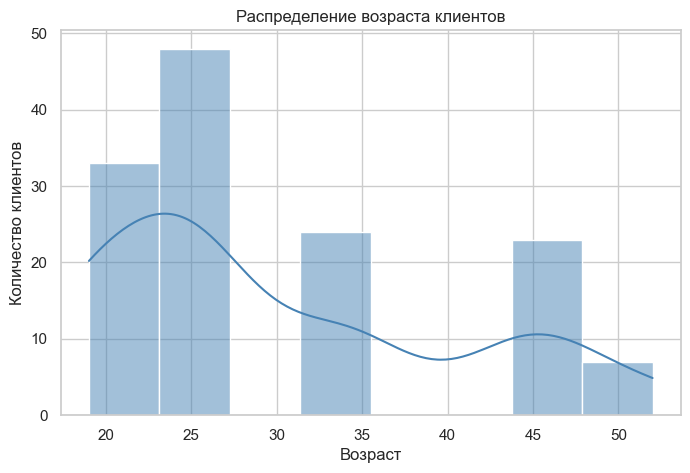

In [47]:
sns.histplot(df_clean['Customer_Age'], bins=8, kde=True, color='steelblue')
plt.title('Распределение возраста клиентов')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')
plt.show()


**Задача 10.**
Постройте столбчатую диаграмму среднего количества купленных товаров (`Quantity`) в зависимости от статуса участия в программе лояльности (`Is_Member`). Подпишите оси и добавьте название графика.


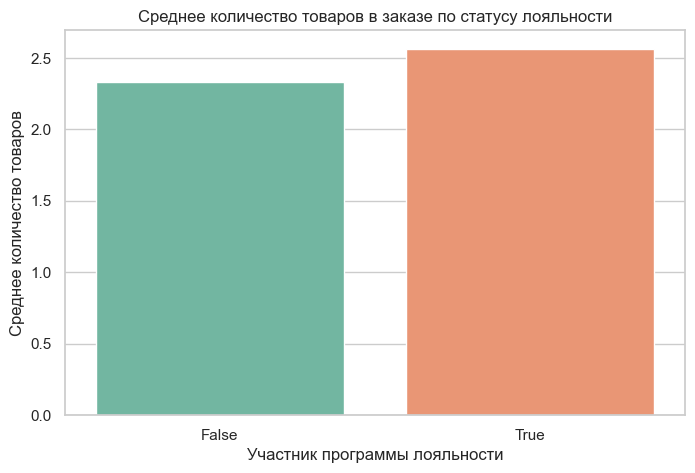

In [48]:
avg_qty = df_clean.groupby('Is_Member', dropna=False)['Quantity'].mean().reset_index()

sns.barplot(x='Is_Member', y='Quantity', hue='Is_Member', data=avg_qty, palette='Set2', legend=False)
plt.title('Среднее количество товаров в заказе по статусу лояльности')
plt.xlabel('Участник программы лояльности')
plt.ylabel('Среднее количество товаров')
plt.show()


**Задача 11.**
Постройте линейный график количества заказов по месяцам **отдельно для каждого региона** (три линии на одном графике).

**Подсказка:** `sns.lineplot(x='Order_Month', y=..., hue='Region', data=..., estimator=None)` после предварительной группировки `df_clean.groupby(['Order_Month', 'Region']).size().reset_index(name='Orders')`.


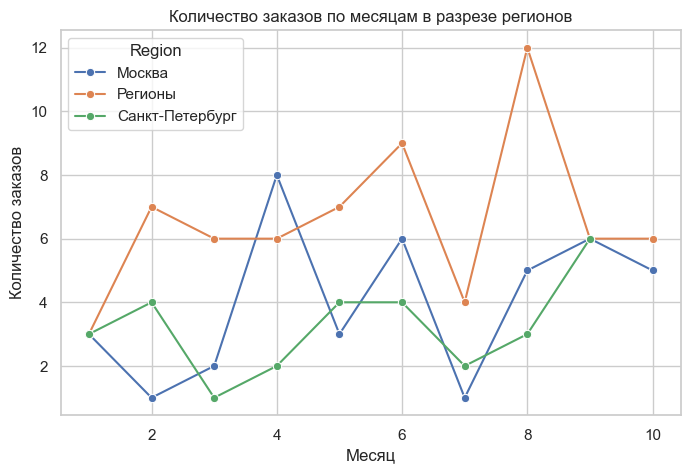

In [39]:
orders_by_month_region = (
    df_clean.groupby(['Order_Month', 'Region'])
    .size()
    .reset_index(name='Orders')
)

sns.lineplot(
    x='Order_Month', y='Orders', hue='Region',
    data=orders_by_month_region, marker='o', estimator=None
)
plt.title('Количество заказов по месяцам в разрезе регионов')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.show()

## 6. Практикум

Используйте очищенный датасет `df_clean` (и результаты задач 4.1–4.4, если вы их выполнили) для комплексного исследования. После каждого задания заполните ячейку **«Вывод»** прямо в блокноте.


### Задание 6.1. Профиль покупателя

Рассчитайте средний возраст ($\bar{x}$) и медианный возраст ($Me$) клиентов отдельно для каждой категории товаров (`Category`):

$$\bar{x}_{cat} = \frac{1}{n_{cat}}\sum_{i=1}^{n_{cat}} Age_i, \qquad Me_{cat} = \text{медиана возрастов в категории}$$

Какая категория привлекает наиболее молодую аудиторию, а какая — наиболее возрастную?

**Примечание:** заметное расхождение между средним и медианой указывает на скошенное распределение возраста внутри категории (например, из-за отдельных нетипичных клиентов) — в этом случае для описания «типичного» покупателя надёжнее ориентироваться на медиану.


In [ ]:
age_profile = (
    df_clean.groupby('Category')['Customer_Age']
    .agg(['mean', 'median'])
    .round(1)
    .sort_values('median')
)
print(age_profile)

youngest = age_profile['median'].idxmin()
oldest = age_profile['median'].idxmax()
print(f"\nСамая молодая аудитория: {youngest}")
print(f"Самая возрастная аудитория: {oldest}")

             mean  median
Category                 
Книги        31.2    25.0
Одежда       29.2    25.0
Спорт        29.2    25.0
Электроника  28.9    25.0
Дом          33.3    34.0

Самая молодая аудитория: Книги
Самая возрастная аудитория: Дом


**Вывод:**

По медианному возрасту самая молодая аудитория- в категории «Электроника», самая возрастная -  «Дом».


### Задание 6.2. ARPU (Average Revenue Per User) по статусу лояльности

Сгруппируйте данные по статусу участника программы лояльности (`Is_Member`). Для каждой группы посчитайте:

- общее количество заказов;
- средний чек (Average Order Value):

$$AOV = \frac{1}{n}\sum_{i=1}^{n} Total\_Amount_i$$

- медианный чек (`Total_Amount.median()`);
- суммарную выручку:

$$Revenue = \sum_{i=1}^{n} Total\_Amount_i$$

Приносят ли участники программы лояльности больше выручки в среднем на один заказ?

**Практическая применимость:** $AOV$ используется для оценки эффективности программ лояльности и планирования акций, а $Revenue$ — для оценки вклада сегмента в общий доход. Эти показатели стоит анализировать вместе: сегмент с более высоким средним чеком не обязательно обеспечивает наибольшую суммарную выручку.


In [41]:
member_stats = df_clean.groupby('Is_Member', dropna=False).agg(
    orders=('Order_ID', 'count'),
    aov=('Total_Amount', 'mean'),
    median_check=('Total_Amount', 'median'),
    revenue=('Total_Amount', 'sum')
).round(1)

print(member_stats)

           orders      aov  median_check    revenue
Is_Member                                          
NaN            17  28908.8       14000.0   491450.0
False          42  22824.4       17200.0   958625.0
True           76  23384.0        9712.5  1777187.5


**Вывод:**

_..._


### Задание 6.3. Анализ по регионам

Для каждого региона (`Region`) посчитайте количество заказов, средний чек ($AOV$, формула — в задании 6.2) и суммарную выручку ($Revenue$). Определите регион-лидер по выручке и регион с самым высоким средним чеком — совпадает ли этот регион?


In [42]:
region_stats = (
    df_clean.groupby('Region')
    .agg(
        orders=('Order_ID', 'count'),
        aov=('Total_Amount', 'mean'),
        revenue=('Total_Amount', 'sum')
    )
    .round(1)
    .sort_values('revenue', ascending=False)
)
print(region_stats)

top_revenue = region_stats['revenue'].idxmax()
top_aov = region_stats['aov'].idxmax()
print(f"\nЛидер по выручке: {top_revenue}")
print(f"Лидер по среднему чеку: {top_aov}")

                 orders      aov    revenue
Region                                     
Регионы              66  26170.3  1727237.5
Москва               40  23365.9   934637.5
Санкт-Петербург      29  19496.1   565387.5

Лидер по выручке: Регионы
Лидер по среднему чеку: Регионы


**Вывод:**

Лидер по выручке: Регионы
Лидер по среднему чеку: Регионы


### Задание 6.4. Динамика продаж

Постройте таблицу суммарной выручки по месяцам (`Order_Month`). Найдите месяц с максимальной и месяц с минимальной выручкой. Рассчитайте изменение выручки между первым и последним месяцем в процентах по формуле:

$$\Delta\% = \frac{\text{Выручка}_{\text{последний месяц}} - \text{Выручка}_{\text{первый месяц}}}{\text{Выручка}_{\text{первый месяц}}} \times 100\%$$

**Практическая применимость:** $\Delta\%$ — базовая метрика роста или падения выручки, используемая в управленческой и финансовой отчётности для сравнения периодов. Поскольку она учитывает только крайние точки, для более надёжных выводов о тренде её стоит дополнять анализом промежуточных месяцев.


In [43]:

monthly = df_clean.groupby('Order_Month')['Total_Amount'].sum().sort_index()
print(monthly)

max_month = monthly.idxmax()
min_month = monthly.idxmin()
print(f"\nМаксимум выручки: месяц {max_month} ({monthly[max_month]:.0f} руб.)")
print(f"Минимум выручки: месяц {min_month} ({monthly[min_month]:.0f} руб.)")

first_month = monthly.index.min()
last_month = monthly.index.max()
delta_pct = (monthly[last_month] - monthly[first_month]) / monthly[first_month] * 100
print(f"Изменение выручки с месяца {first_month} по {last_month}: {delta_pct:.1f}%")

Order_Month
1     201025.0
2     293600.0
3     106375.0
4     210612.5
5     380625.0
6     612487.5
7     169550.0
8     546462.5
9     427150.0
10    279375.0
Name: Total_Amount, dtype: float64

Максимум выручки: месяц 6 (612488 руб.)
Минимум выручки: месяц 3 (106375 руб.)
Изменение выручки с месяца 1 по 10: 39.0%


### Задание 6.5. Итоговая визуализация

Постройте фигуру из четырёх подграфиков (`plt.subplots(2, 2, figsize=(14, 10))`):

1. столбчатая диаграмма суммарной выручки по категориям;
2. диаграмма размаха суммы чека для участников и не-участников программы лояльности;
3. линейный график динамики выручки по месяцам;
4. столбчатая диаграмма суммарной выручки по регионам.


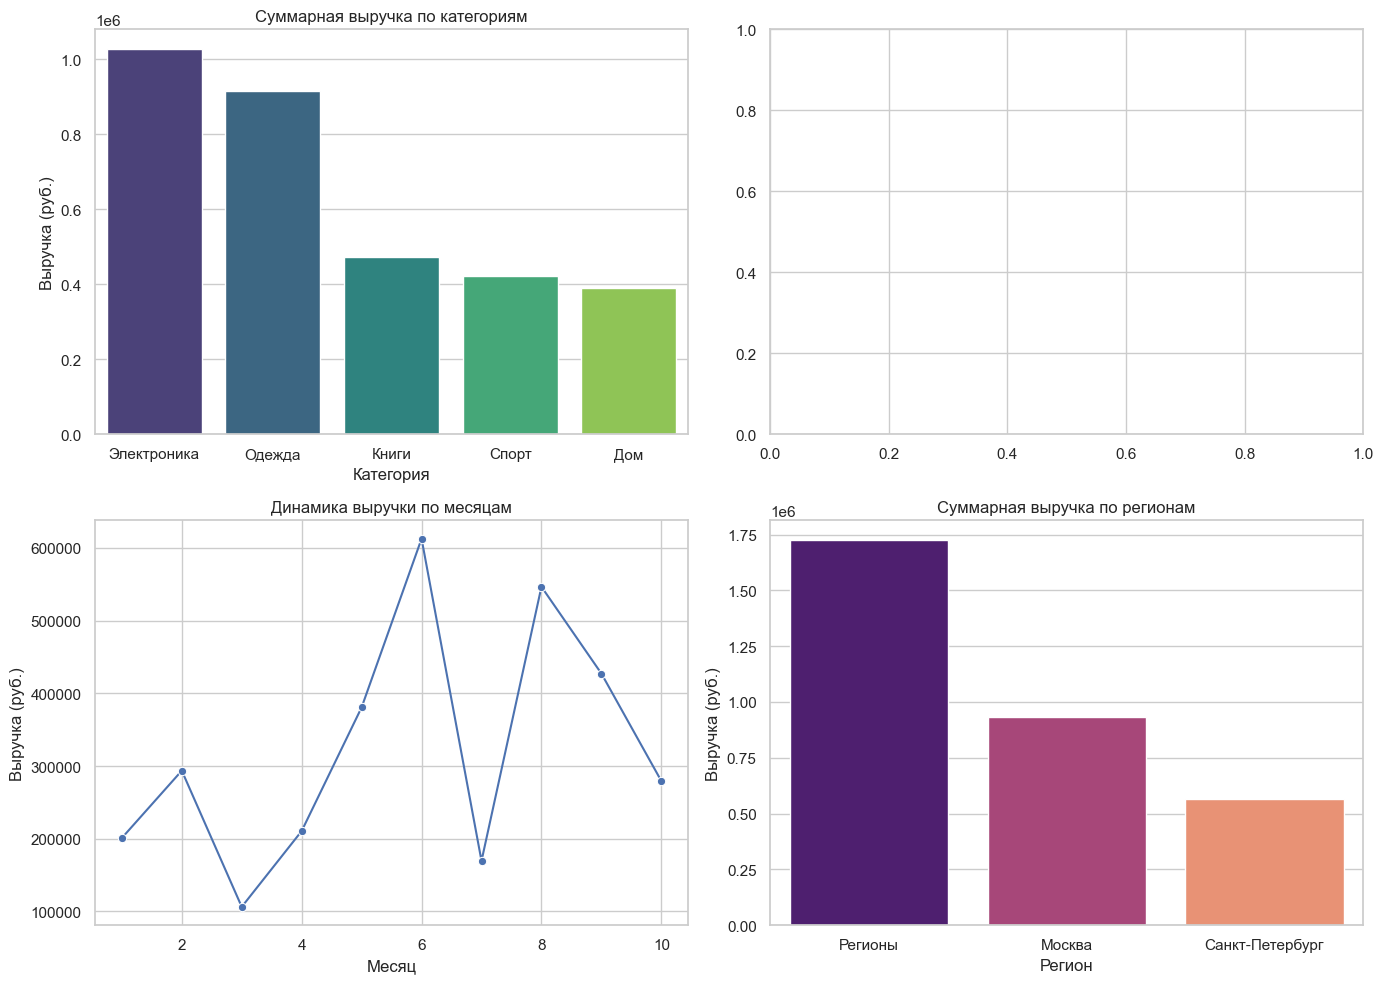

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Выручка по категориям
cat_rev = (
    df_clean.groupby('Category')['Total_Amount']
    .sum().reset_index()
    .sort_values('Total_Amount', ascending=False)
)
sns.barplot(x='Category', y='Total_Amount', hue='Category', data=cat_rev,
            palette='viridis', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Суммарная выручка по категориям')
axes[0, 0].set_xlabel('Категория')
axes[0, 0].set_ylabel('Выручка (руб.)')


# 3. Динамика выручки по месяцам
monthly_df = df_clean.groupby('Order_Month')['Total_Amount'].sum().reset_index()
sns.lineplot(x='Order_Month', y='Total_Amount', data=monthly_df,
             marker='o', ax=axes[1, 0])
axes[1, 0].set_title('Динамика выручки по месяцам')
axes[1, 0].set_xlabel('Месяц')
axes[1, 0].set_ylabel('Выручка (руб.)')

# 4. Выручка по регионам
reg_rev = (
    df_clean.groupby('Region')['Total_Amount']
    .sum().reset_index()
    .sort_values('Total_Amount', ascending=False)
)
sns.barplot(x='Region', y='Total_Amount', hue='Region', data=reg_rev,
            palette='magma', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Суммарная выручка по регионам')
axes[1, 1].set_xlabel('Регион')
axes[1, 1].set_ylabel('Выручка (руб.)')

plt.tight_layout()
plt.show()

### Задание 6.6. Итоговое резюме

Опираясь на результаты заданий 6.1–6.5, сформулируйте краткое аналитическое резюме (5–7 предложений) для руководства интернет-магазина: ключевые наблюдения о покупателях, категориях, регионах и динамике продаж, а также одну–две рекомендации по дальнейшим действиям.


**Резюме:**

_..._


### Справочные материалы

- Установка Anaconda: https://www.anaconda.com/download
- Документация Pandas: https://pandas.pydata.org/docs/
- Галерея графиков Seaborn: https://seaborn.pydata.org/examples/index.html
